**Bibliotecas**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 8)

**Dataset**


In [ ]:
def get_linear_curve(x, w , b=0, noise_scale=0):#noise scale(escala de ruído)
  return w*x +b + noise_scale*np.random.randn(x.shape[0])

In [ ]:
x = np.arange(-10, 20 , 0.5)
y = get_linear_curve(x, 1.8, 32, noise_scale=2.5)

In [ ]:
x.shape, y.shape

((60,), (60,))

Text(0.5, 0, '°C')

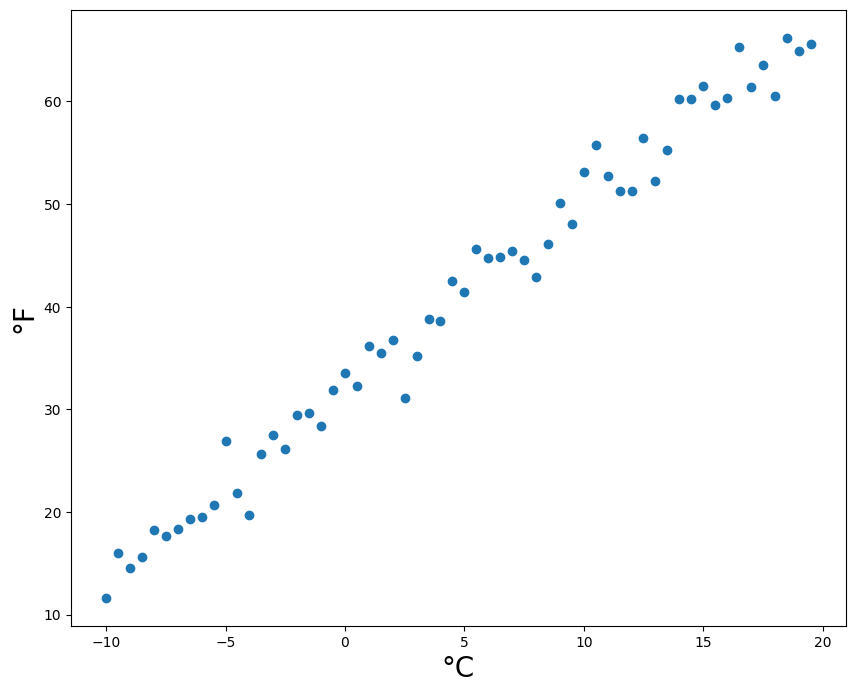

In [ ]:
plt.scatter(x, y)

plt.ylabel('°F', fontsize=20)

plt.xlabel('°C', fontsize=20)

**Inicialização**

In [ ]:

w = np.random.rand(1)
b = 0

**Feedforward**

In [ ]:
def forward(inputs, w, b):
  return w*inputs + b

**Mean Squared**

In [ ]:
def mse(Y, y):
  return (Y-y)**2

In [ ]:
v = np.array([3, 4, 5])
u = np.array([3.2, 4.5, 4.8])
mse(v , u)

array([0.04, 0.25, 0.04])

 **Backpropagation**

In [ ]:
def backpropagation(inputs, outputs, targets, w, b, lr):
 dw = lr*(-2*inputs*(targets-outputs)).mean()
 db = lr*(-2*(targets-outputs)).mean()

 w -= dw
 b -= db
 return w, b

In [ ]:
def model_fit(inputs, target, w, b, epochs=200, lr=0.001):
    for epoch in range(epochs):
        outputs = forward(inputs, w, b)
        loss = np.mean(mse(target, outputs))
        w, b = backpropagation(inputs, outputs, target, w, b, lr)

        if (epoch + 1) % (epochs / 10) == 0:
            print(f'Epoch: [{(epoch + 1)}/{epochs}] Loss: [{loss:.4f}]')

    return w, b

In [ ]:
x = np.arange(-10,20,2)
Y = get_linear_curve(x, w = 1.8, b =32)

**Inicialização**


In [ ]:

w = np.random.randn(1)
b = np.zeros(1)

In [ ]:
w, b = model_fit(x, Y, w , b, epochs=2000, lr=0.002)
print(f'w: {w[0]:.3f}, b: {b[0]:.3f}')

Epoch: [200/2000] Loss: [224.6845]
Epoch: [400/2000] Loss: [60.1876]
Epoch: [600/2000] Loss: [16.1228]
Epoch: [800/2000] Loss: [4.3189]
Epoch: [1000/2000] Loss: [1.1569]
Epoch: [1200/2000] Loss: [0.3099]
Epoch: [1400/2000] Loss: [0.0830]
Epoch: [1600/2000] Loss: [0.0222]
Epoch: [1800/2000] Loss: [0.0060]
Epoch: [2000/2000] Loss: [0.0016]
w: 1.802, b: 31.956


**Gráfico**

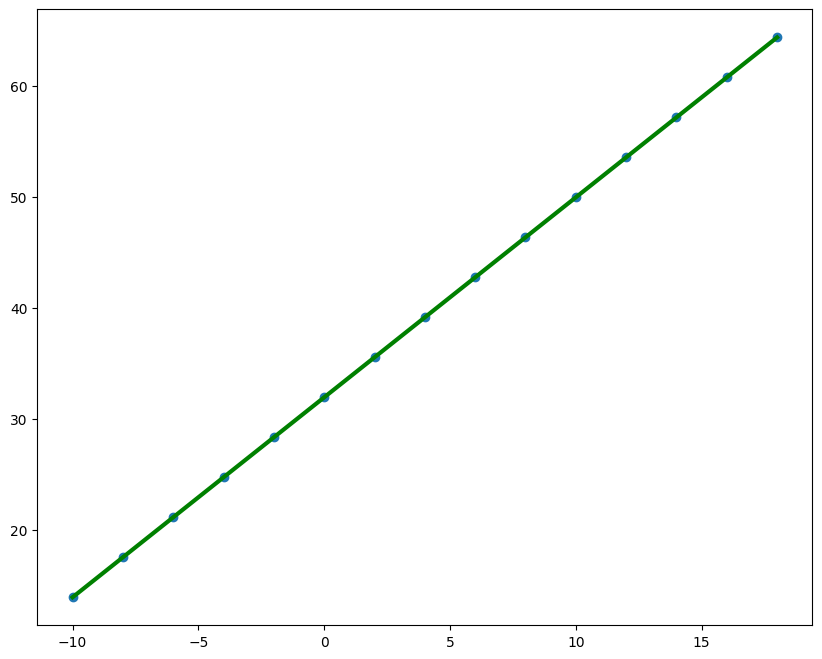

In [ ]:
plt.scatter(x, Y)
plt.plot(x, get_linear_curve(x, w, b), 'g' , lw=3)
